In [1]:
from paths import PROJECT_ROOT
import sys
sys.path.insert(0, PROJECT_ROOT)

import os
from paper_figures.cache_utils import activations_cached, connections_cached
from connectome.visualization.random_networks_plots.plot_config import apply_plot_style
plots_dir = os.path.join(PROJECT_ROOT, "plots")
from connectome.visualization.random_networks_plots.plot_config import RANDOMIZATIONS
NUM_PASSES = 3

apply_plot_style()

# Create plots directory if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)

from connectome.data_helpers import load_neuron_coordinates

neuron_position_data = load_neuron_coordinates()

# Heavy cached computations
connections_dict = RANDOMIZATIONS.get_enabled(connections_cached())
activations_dict = RANDOMIZATIONS.get_enabled(activations_cached(NUM_PASSES))

/home/eudald/Escriptori/altres/connectome/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: '/home/eudald/Escriptori/altres/connectome/notebooks/visualization/task_images/t5.png'

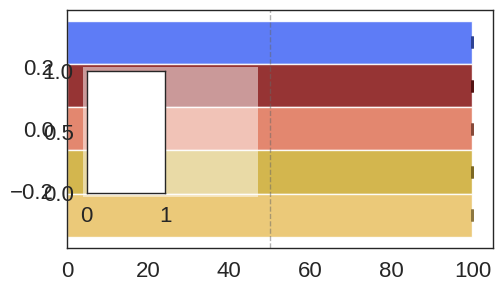

In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.image import imread
import seaborn as sns

plt.close('all')
sns.set_theme(font_scale=1.4, style="white")

# Reload submodules and import directly from them
import importlib
from connectome.visualization import plot_config, models_accuracy
from connectome.visualization import plot_helpers as plots
importlib.reload(plot_config)
importlib.reload(models_accuracy)
importlib.reload(plots)
plot_task_accuracy_row = models_accuracy.plot_task_accuracy_row

apply_plot_style()
from connectome.visualization.random_networks_plots.plot_config import PLOT_STYLE_PARAMS

font_size = PLOT_STYLE_PARAMS["font.size"]
task_images_dir = os.path.join(PROJECT_ROOT, "paper_figures", "task_images")

fig = plt.figure(figsize=(11, 9.2))
gs = GridSpec(
    3,
    2,
    figure=fig,
    width_ratios=[1.0, 1.1],
    height_ratios=[1, 1, 1],
    left=0.07,
    right=0.98,
    top=0.98,
    bottom=0.08,
    wspace=0.24,
    hspace=0.24,
)

ax_color = fig.add_subplot(gs[0, 0])
plot_task_accuracy_row(
    'Color\ndiscrimination',
    ax=ax_color,
    show_xlabel=False,
    show_chance_label=True,
    chance_fontsize=14,
    chance_y=-0.3,
)
ax_color.text(-0.08, 1.06, 'a', transform=ax_color.transAxes,
              fontsize=font_size, fontweight='bold', va='bottom', ha='right')

ax_shape = fig.add_subplot(gs[1, 0], sharex=ax_color)
plot_task_accuracy_row('Shape\nrecognition', ax=ax_shape, show_xlabel=False, show_chance_label=False)
ax_shape.text(-0.08, 1.06, 'b', transform=ax_shape.transAxes,
              fontsize=font_size, fontweight='bold', va='bottom', ha='right')

ax_numerical = fig.add_subplot(gs[2, 0], sharex=ax_color)
plot_task_accuracy_row('Numerical\ndiscrimination', ax=ax_numerical, show_xlabel=True, show_chance_label=False)
ax_numerical.text(-0.08, 1.06, 'e', transform=ax_numerical.transAxes,
                  fontsize=font_size, fontweight='bold', va='bottom', ha='right')

ax_legend = fig.add_subplot(gs[0, 1])
ax_legend.axis('off')
handles, labels = ax_color.get_legend_handles_labels()
ax_legend.legend(handles, labels, loc='center', ncol=2, frameon=False, fontsize=15)

mid_gs = gs[1, 1].subgridspec(1, 2, width_ratios=[1.68, 0.68], wspace=0.18)
collage_gs = mid_gs[0].subgridspec(2, 2, hspace=0.1, wspace=0.06)

ax_left_circle = fig.add_subplot(collage_gs[0, 0])
ax_left_star = fig.add_subplot(collage_gs[1, 0])
ax_right_circle = fig.add_subplot(collage_gs[0, 1])
ax_right_star = fig.add_subplot(collage_gs[1, 1])


def show_half_marked_image(ax, image_name):
    image = imread(os.path.join(task_images_dir, image_name))
    ax.imshow(image)
    ax.axvline((image.shape[1] - 1) / 2, color='white', linestyle=(0, (4, 4)), linewidth=2, alpha=0.95)
    ax.set_axis_off()
    ax.set_aspect('equal')


show_half_marked_image(ax_left_circle, 'left_circle.png')
show_half_marked_image(ax_left_star, 'left_star.png')
show_half_marked_image(ax_right_circle, 'right_circle.png')
show_half_marked_image(ax_right_star, 'right_star.png')

for ax in (ax_right_circle, ax_right_star):
    pos = ax.get_position()
    ax.set_position([pos.x0 - 0.018, pos.y0, pos.width, pos.height])

ax_left_circle.set_title('Training\nimages', fontsize=14, pad=10)
ax_right_circle.set_title('Test\nimages', fontsize=14, pad=10)
ax_left_circle.text(-0.34, 1.14, 'c', transform=ax_left_circle.transAxes,
                    fontsize=font_size, fontweight='bold', va='bottom', ha='right')

ax_transfer_acc = fig.add_subplot(mid_gs[1])
transfer_labels = ['Train', 'Test']
transfer_values = [63, 48]
transfer_colors = ['#6c757d', '#adb5bd']
bars = ax_transfer_acc.bar(transfer_labels, transfer_values, color=transfer_colors, width=0.62)
for bar, value in zip(bars, transfer_values):
    ax_transfer_acc.text(bar.get_x() + bar.get_width() / 2, value + 2, f'{value}%',
                         ha='center', va='bottom', fontsize=13)
ax_transfer_acc.set_ylabel('Accuracy (%)', fontsize=14)
ax_transfer_acc.set_ylim(0, 100)
ax_transfer_acc.spines[['top', 'right']].set_visible(False)
ax_transfer_acc.yaxis.grid(True, linestyle='--', alpha=0.3)
ax_transfer_acc.tick_params(axis='x', labelsize=13)
ax_transfer_acc.tick_params(axis='y', labelsize=12)
ax_transfer_acc.text(-0.28, 1.07, 'd', transform=ax_transfer_acc.transAxes,
                     fontsize=font_size, fontweight='bold', va='bottom', ha='right')

ax_weber = fig.add_subplot(gs[2, 1])
plots.plot_weber_by_randomization(
    folder=os.path.join(PROJECT_ROOT, "supplementary_data"),
    min_weber=1.2,
    ax=ax_weber,
    show_legend=False
)
ax_weber.text(-0.08, 1.02, 'f', transform=ax_weber.transAxes,
              fontsize=font_size, fontweight='bold', va='bottom', ha='right')

plt.show()

fig.savefig(os.path.join(plots_dir, "figure_3.pdf"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(plots_dir, "figure_3.png"), dpi=300, bbox_inches='tight')

In [3]:
models_accuracy.task_accuracy_table(include_errors=True)


,Color Discrimination,Shape Recognition,Numerical Discrimination
Network,,,
Biological,100.00 +/- 0.00,64.00 +/- 1.00,71.47 +/- 0.90
Unconstrained,100.00 +/- 0.00,70.00 +/- 3.00,82.98 +/- 0.75
Connection-pruned,100.00 +/- 0.00,69.00 +/- 2.00,78.13 +/- 0.82
Binned,100.00 +/- 0.00,63.00 +/- 1.00,65.48 +/- 0.95
Neuron binned,100.00 +/- 0.00,60.00 +/- 2.00,65.60 +/- 0.95


In [4]:
plots.weber_accuracy_table(
    folder=os.path.join(PROJECT_ROOT, "supplementary_data"),
    min_weber=1.2,
)

,Biological,Unconstrained,Connection-pruned,Binned,Neuron binned
Weber Ratio,,,,,
1.333,64.58,79.58,73.75,54.17,60.00
1.500,63.89,75.00,69.44,58.33,57.22
1.667,65.00,81.67,70.42,55.83,58.75
2.000,68.83,79.33,76.50,63.67,64.67
2.500,75.42,87.50,83.33,70.83,70.42
3.000,75.83,86.67,80.83,71.94,66.11
4.000,78.33,86.25,83.33,68.75,70.42
5.000,85.42,95.42,92.92,83.33,82.50


In [5]:
# here